In [49]:
import numpy as np
#from scipy.integrate import odeint
from scipy.integrate import solve_ivp as sl
import matplotlib.pyplot as plt
import cvxpy as cp

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D  # Solo si se necesita para n=3
%matplotlib widget

In [50]:


#CASO DE N ROBOTS EN UN ESPACIO n-DIMENSIONAL

#todos los agentes siguen las mismas ecuaciones de trayectoria

#Definimos en una función las ecuaciones de la trayectoria 
np.random.seed(123)

#Función para la trayectoria de la lemniscata


def lemniscata(w,a,b):
    fx = a*np.cos(w) / (1 + np.sin(w)**2)  # Coordenada X
    fy = b*np.sin(w) * np.cos(w) / (1 + np.sin(w)**2)  # Coordenada Y
    return np.array([fx, fy])


def flor_2m_petalos(w, radius=2, modulation=20, m=2):

    # Fórmula paramétrica para una flor de 6 pétalos
    r = radius * (1 + modulation * np.sin(m * w))  # Modulación para generar los pétalos
    x = r * np.cos(w)  # Coordenada x
    y = r * np.sin(w)  # Coordenada y

    return np.array([x, y])

#Descomentar de la función la trayectoria que se quiera seguir :) 

def fun(w):
    #f1 = 15*np.sin(2*w)
    #f2 = 30*np.sin(w)*(np.sqrt(0.5*(1-0.5*(np.sin(w))**2)))
    #f3 = 3+5*np.cos(2*w)


    #Lemniscata de dos focos 
    #[f1,f2]=lemniscata(w,40,80)    

    #Flor de 2m pétalos
    [f1,f2]=flor_2m_petalos(w,2,20,2)

    #f1 = 10*np.sin(w)+20*np.sin(2*w)
    #f2 = 10*np.cos(w)-20*np.cos(2*w)
    #f3 = -40*np.sin(3*w)
    #f1 = (20 + 15*np.cos(2*w))*np.cos(w)
    #f2 = (20 + 15*np.cos(2*w))*np.sin(w)
    #f3 = 15 * np.sin(2*w)

    #return np.array([f1,f2,f3])
    return np.array([f1, f2])

#funciones phi
def phi(vec_pos):
    f = fun(vec_pos[-1])
    return vec_pos[:-1] - f

# calculamos la derivada de las ecuaciones de la trayectoria
def d_fun(w):
    #derivada central
    h = 1e-8 #paso
    df = (fun(w+h)-fun(w-h))/(2*h)
    return df

#matriz lapaciana de un grafo (los agentes están comunicados con los vecinos adyacentes)
def grafo_L(N):
    #N: nº de agentes 
    L = np.zeros([N,N])  
    
    # Llenar la diagonal con 2 
    np.fill_diagonal(L, 2)
    
    # Llenar las diagonales justo arriba y abajo de la diagonal principal con -1
    np.fill_diagonal(L[:, 1:], -1)
    np.fill_diagonal(L[1:, :], -1)
    
    # Llenar las esquinas con -1
    L[0, -1] = -1
    L[-1, 0] = -1
    
    return L

def vector_field(xi,k,n,N,ww,kc,L):
    #xi: posiciones de todos los agentes (vector columna con las 4 coordenadas )
    #t: tiempo
    #k: ganancias positivas
    #n: dimensiones 
    #N: nº de agentes 
    #L: matriz laplaciana de un grafo

    lista = np.arange(0,(n+1)*N+1,(n+1))
    k = k*N

    PHI = np.zeros(n*N) #lista vacía de funciones surface
    df = np.zeros(n*N)  #lista vacía de las derivadas 
    w = np.zeros(N)     #lista vacía para las coordenadas virtuales

    j = 0 
    for i in lista[:-1]: 
        x = xi[i:i+(n+1)]               #coordenada inicial + virtual de cada agente
        PHI[i-j:(i-j)+n] = phi(x)       #función surface 
        df[i-j:(i-j)+n] = d_fun(x[-1])  #derivada 
        w[j] = x[-1]                    #coordenadas virtuales 
        j += 1

    xi_eta = (-1)**n*df-k*PHI

    #sumatorio
    l = k*PHI*df
    # Convertir la matriz l en una matriz de n filas
    matriz_l = l.reshape((N, -1))
    #sumar a los largo del eje de las filas 
    suma = np.sum(matriz_l, axis=1)

    #función de coordinación 
    c = -L@np.transpose(w-ww)
    
    xi4 = (-1)**n+suma+kc*c

    #path-following guiding vector field 
    xi_eta = np.concatenate((xi_eta.reshape((N,n)),np.array([xi4]).T),axis=1)
    xi_eta = xi_eta.reshape((N*(n+1),-1)).T

    #print(PHI)

    return xi_eta[0]

#------------------------------------------------------------------------

In [51]:
#Proyección de las coordenadas espaciales del estado (excluye la w)
def P_matrix(n):
    A=np.eye(n+1)
    A[n,n]=0
    return (A)


#Función h que determina la distancia entre dos robots en función de la distancia de seguridad
def h_func(xi,xj,R,n):
    dist=np.linalg.norm(P_matrix(n) @ (xi-xj))
    return dist**2 - R**2


def solve_optimization(X, z, P, alpha, n, N, R, i):
    """
    Resuelve el problema de optimización para un robot i utilizando cvxpy.
    La restricción se aplica para todos los robots j != i.
    :param X: Vector nominal (numpy array de dimensión n+1 para todos los robots)
    :param z: Estados espaciales (numpy array de tamaño N x (n+1))
    :param P: Matriz de proyección (numpy array de tamaño (n+1) x (n+1))
    :param alpha: Escalar para la restricción
    :param h: Valores de h_ij (numpy array de tamaño N para cada par i, j)
    :param n: Dimensiones del espacio físico
    :param N: Número total de robots
    :param i: Índice del robot que estamos optimizando
    :return: Solución óptima para \(\hat{\mathbf{x}}^{[i]}\)
    """
    # Variables
    adjusted_state_i = cp.Variable(n+1)  # Variable optimizada: \(\hat{\mathbf{x}}^{[i]}\)
    nominal_state_i = X  # Estado nominal del robot i

    # Objetivo: minimizar la distancia cuadrática
    objective = cp.Minimize(0.5 * cp.sum_squares(adjusted_state_i - nominal_state_i))

    # Restricciones
    constraints = []
    for j in range(N):  # Iterar sobre todos los robots
        if j != i:  # Asegurarnos de que j != i
            delta_z = z[j*(n+1):(j*(n+1) +(n+1))] - z[i*(n+1):(i*(n+1) +(n+1))]  # Diferencia en los estados espaciales
            constraint_rhs = (alpha / 4) * h_func(z[i*(n+1):(i*(n+1) +(n+1))],z[j*(n+1):(j*(n+1) +(n+1))],R,n)**3  # Lado derecho de la restricción
            constraints.append(delta_z @ P.T @ adjusted_state_i <= constraint_rhs)

    # Formulación del problema
    problem = cp.Problem(objective, constraints)

    # Resolver
    problem.solve()

    if problem.status in ["optimal", "feasible"]:
        return adjusted_state_i.value  # Solución óptima
    else:
        raise ValueError(f"Problema de optimización no resoluble: {problem.status}")


#Cálculo del campo considerando evitar colisiones
def safe_vector_field(t,xi,R,k,n,N,ww,kc,L,alpha):
    
    X=vector_field(xi,k,n,N,ww,kc,L)  #almacena el campo nominal
    X_hat=[]  #prepara el vector para el campo ajustado 

    for i in range(N):
        state_i=xi[i*(n+1):(i+1)*(n+1)]   #estado actual del robot i
        adjusted_state_i=cp.Variable((n+1))    #variables para la optimización

        #Definir las restricciones de optimización
        
        X_hat.append(solve_optimization(X[i*(n+1):(i+1)*(n+1)], xi, P_matrix(n), alpha, n, N, R, i))


    return np.concatenate(X_hat)

In [52]:
#representación gráfica 

def graph_trajectories(sol,n,N):
    if n==2:
        # Crear la figura y los ejes bidimensionales
        fig = plt.figure()
        ax = fig.add_subplot()

        lista = np.arange(0, (n+1)*N+1, (n+1))  # Índices correspondientes a los robots
        # Parámetros de la lemniscata
        w = np.linspace(0, 2 * np.pi, 1000)  # Valores del parámetro w
        [f_x,f_y]=fun(w)

        # Trazar la lemniscata
        ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
        count = 1  # Contador para etiquetar los robots

        for i in lista[:-1]: 
            # Generar colores aleatorios para cada robot
            r = np.round(np.random.rand(), 1)
            g = np.round(np.random.rand(), 1)
            b = np.round(np.random.rand(), 1)
            
            # Trazar las trayectorias en 2D (x, y)
            ax.plot(sol.y[i, :], sol.y[i+1, :], color=[r, g, b])
            
            # Punto inicial
            ax.scatter(sol.y[i, 0], sol.y[i+1, 0], marker='o', color=[r, g, b])
            ax.text(sol.y[i, 0], sol.y[i+1, 0], str(count), color='red')
            
            # Punto final
            ax.scatter(sol.y[i, -1], sol.y[i+1, -1], marker='^', color=[r, g, b])
            ax.text(sol.y[i, -1], sol.y[i+1, -1], str(count))
            
            count += 1  # Incrementar el contador

        # Configuración de los ejes
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Trayectoria de los agentes en 2D')

        # Mostrar la gráfica
        plt.show()
    if n==3:
        fig = plt.figure()
        ax = fig.add_subplot(projection='3d')

        lista = np.arange(0,(n+1)*N+1,(n+1))

        count = 1 

        for i in lista[:-1]: 
            r = np.round(np.random.rand(),1)
            g = np.round(np.random.rand(),1)
            b = np.round(np.random.rand(),1)
            ax.plot(sol.y[i,:], sol.y[i+1,:], sol.y[i+2,:], color = [r,g,b])
            ax.scatter(sol.y[i,0],sol.y[i+1,0], sol.y[i+2,0], marker='o',color = [r,g,b])
            ax.text(sol.y[i,0],sol.y[i+1,0], sol.y[i+2,0], str(count),color ='red')
            ax.scatter(sol.y[i,-1],sol.y[i+1,-1],sol.y[i+2,-1], marker='^',color = [r,g,b])
            ax.text(sol.y[i,-1],sol.y[i+1,-1],sol.y[i+2,-1],str(count))
            count = count + 1


        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title('Trayectoria de los agentes')
        plt.show()

In [53]:
def animate_trajectories(sol, n, N, tolerance, limits):
    """
    Crea una animación de las trayectorias de los agentes en 2D o 3D según la dimensión n,
    eliminando fotogramas repetidos y fijando las dimensiones de los ejes.
    
    :param sol: Resultado de la simulación que contiene las trayectorias de los robots.
    :param n: Dimensiones del espacio (2 o 3).
    :param N: Número de agentes.
    :param tolerance: Tolerancia para identificar fotogramas repetidos.
    :param limits: Límite fijo para los ejes (mínimo y máximo).
    """
    # Definir los índices de los robots
    lista = np.arange(0, (n+1)*N+1, (n+1))

    # Crear la figura
    fig = plt.figure()
    if n == 2:
        ax = fig.add_subplot()  # 2D
        w = np.linspace(0, 2 * np.pi, 1000)  # Valores del parámetro w para la lemniscata
        [f_x,f_y]=fun(w)
        ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
        ax.set_xlim(limits)  # Límites fijos para x
        ax.set_ylim(limits)  # Límites fijos para y
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Trayectoria de los agentes en 2D')

    elif n == 3:
        ax = fig.add_subplot(projection='3d')  # 3D
        ax.set_xlim(limits)  # Límites fijos para x
        ax.set_ylim(limits)  # Límites fijos para y
        ax.set_zlim(limits)  # Límites fijos para z
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title('Trayectoria de los agentes en 3D')

    # Generar colores aleatorios para cada robot
    colors = [np.random.rand(3).tolist() for _ in range(N)]

    # Identificar los fotogramas únicos
    unique_frames = [0]  # Siempre incluimos el primer fotograma
    for frame in range(1, len(sol.t)):
        max_diff = np.max(np.abs(sol.y[:, frame] - sol.y[:, unique_frames[-1]]))
        if max_diff > tolerance:
            unique_frames.append(frame)

    # Función de actualización para la animación
    def update(frame_index):
        frame = unique_frames[frame_index]  # Usamos solo los fotogramas únicos
        ax.clear()  # Limpia la figura en cada frame

        if n == 2:
            # Redibujar la lemniscata en cada frame
            ax.plot(f_x, f_y, color='magenta', linestyle='--', label='Lemniscata')
            ax.set_xlim(limits)  # Límites fijos para x
            ax.set_ylim(limits)  # Límites fijos para y
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_title(f'Trayectoria de los agentes en 2D - Tiempo: {sol.t[frame]:.2f}s')

        elif n == 3:
            ax.set_xlim(limits)  # Límites fijos para x
            ax.set_ylim(limits)  # Límites fijos para y
            ax.set_zlim(limits)  # Límites fijos para z
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_zlabel('z')
            ax.set_title(f'Trayectoria de los agentes en 3D - Tiempo: {sol.t[frame]:.2f}s')

        # Dibujar trayectorias y posiciones actuales
        count = 1
        for i, color in zip(lista[:-1], colors):
            x = sol.y[i, :frame]
            y = sol.y[i+1, :frame]
            if len(x) > 0 and len(y) > 0:  # Validar que no estén vacíos
                if n == 2:
                    # Coordenadas para n=2
                    ax.plot(x, y, color=color)  # Dibujar la trayectoria
                    ax.scatter(x[-1], y[-1], color=color, marker='o')  # Posición actual
                    ax.text(x[-1], y[-1], str(count), color='red')
                elif n == 3:
                    # Coordenadas para n=3
                    z = sol.y[i+2, :frame]
                    ax.plot(x, y, z, color=color)  # Dibujar la trayectoria
                    ax.scatter(x[-1], y[-1], z[-1], color=color, marker='o')  # Posición actual
                    ax.text(x[-1], y[-1], z[-1], str(count), color='red')
            count += 1

    # Crear la animación usando solo los fotogramas únicos
    anim = FuncAnimation(fig, update, frames=len(unique_frames), interval=100)

    # Mostrar la animación
    plt.show()

    # Si deseas guardar la animación como un archivo de video:
    anim.save("trayectorias.mp4", fps=15, extra_args=['-vcodec', 'libx264'])


In [54]:
#Parámetro de simulación 
n = 2           #dimensiones del espacio
N = 2           #nº de agentes 
# ki =[1,1,2] #ganancias 
ki =[1,1] #ganancias 
R = 5  #Distancia de seguridad 
alpha=1 #coeficiente de convergencia de potencial de separación

#coordenadas iniciales de los robots 
#pos = np.random.rand(N, n)*100 #filas: dimensiones
                           #columnas: nº de robots

pos = np.random.randint(-50, 51, size=(N, n)) 

#añadimos a la matriz de posiciones la coordenada virtual w 
w = np.ones((N,1)) #ejemplo: todos valen 1 

#concatenamos las dos matrices a lo largo de las filas 
Xi = np.concatenate((pos, w), axis=1)
Xi = Xi.reshape((N*(n+1),-1)).T #apilamos en un vector

#matriz lapaciana de un grafo 
L = grafo_L(N)

#parámetros para la componente de coordinación 
T = 2*np.pi #periodo 
Delta = T/N
kc = 300

ww = np.zeros(N)
for i in range(N):
    ww[i] = i*Delta

#resolvemos las ecuación diferencial 
#sol = odeint(vector_field,Xi[0],t,args=(ki,n,N,ww,kc,L))
sol = sl(safe_vector_field, (0,10),Xi[0],method='LSODA',args=(R,ki,n,N,ww,kc,L,alpha),max_step=0.2) 

capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/scipy/integrate/_ivp/base.py", line 154, in fun
Fatal Python error: F2PySwapThreadLocalCallbackPtr: F2PySwapThreadLocalCallbackPtr: PyLong_AsVoidPtr failed
Python runtime state: initialized
    return self.fun_single(t, y)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/scipy/integrate/_ivp/base.py", line 23, in fun_wrapped
    return np.asarray(fun(t, y), dtype=dtype)
                      ^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/scipy/integrate/_ivp/ivp.py", line 540, in fun
    return fun(t, x, *args)
           ^^^^^^^^^^^^^^^^
  File "/var/folders/z7/7fzwy2zj1h500lg01l_r8r1c0000gn/T/ipykernel_60656/3397493471.py", line 67, in safe_vector_field
  File "/var/folders/z7/7fzwy2zj1h500lg01l_r8r1c0000gn/T/ipykernel_60656/3397493471.py", line 52, in solve_optimization
ValueError

: 

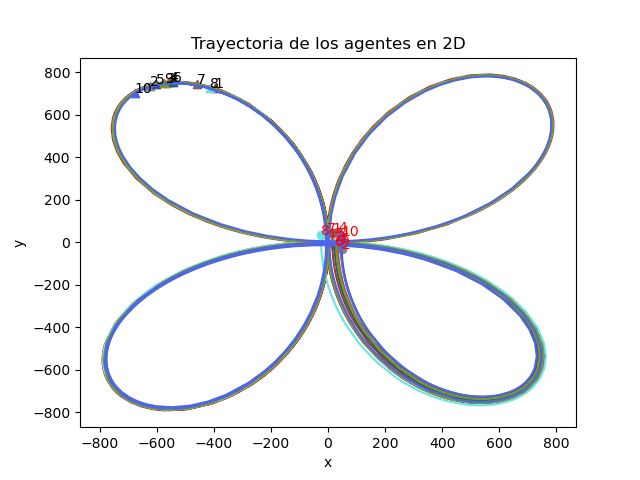

In [ ]:
graph_trajectories(sol,n,N)

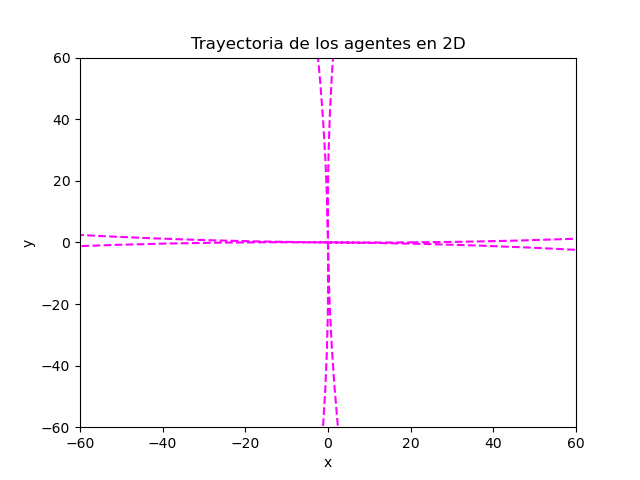

In [ ]:
anim_tolerance=1   #tolerance for duplicate frames during animation
anim_limits=(-60,60)   #Plot limits for animation

animate_trajectories(sol,n,N,anim_tolerance,anim_limits)